# EEGTCNet v2: PhysioNet Motor Imagery Classification

**Key improvements over all previous attempts:**

1. **2x more data**: Use ALL 6 left/right fist runs (R03+R04+R07+R08+R11+R12 = ~90 trials/subject) instead of only 3 MI runs (~45 trials). Motor execution and imagery share cortical substrates.

2. **Channel selection**: Use 16 motor cortex channels instead of all 64 — reduces noise, matches spatial filter dimensions. Channels: Fp1, F3, F4, C3, Cz, C4, P3, Pz, P4, F7, F8, T7, T8, P7, P8, Fz (10-10 naming).

3. **Compact EEGNet-style architecture** (~72k params): Temporal conv → depthwise spatial conv → separable conv → Transformer → GAP → FC. No spatial kernel=3 Conv2D.

4. **S&R augmentation** (Segmentation & Reconstruction): The augmentation strategy used by ALL top-performing models (TCFormer, CCST, MSCFormer). Replaces random noise/shift/flip which can corrupt EEG signals.

5. **Aggressive temporal pooling**: Produces only 20 tokens for the Transformer (vs 140 in EEGTCNet v1). CCST uses 15 tokens. Fewer tokens = less overfitting risk.

**Dataset**: PhysioNet EEG Motor Movement/Imagery (109 subjects, 16ch, 160 Hz, 2 classes)
**Experiment**: Within-subject (80/20)

## 1. Imports & Configuration

In [1]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')


import mne
mne.set_log_level('WARNING')

import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, cohen_kappa_score)

def set_random_seeds(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_random_seeds(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"PyTorch: {torch.__version__}, Device: {device}")

# Dataset constants
N_SUBJECTS = 109
N_CHANNELS = 64  # ALL channels (CCST uses all 64)
SFREQ = 160 # Hz
N_CLASSES = 2 # Left Fist, Right Fist
EPOCH_SAMPLES = 641 # MNE gives 641 for tmax=4.0 @ 160Hz (CCST uses 641)

# All left/right fist runs (execution + imagery)
MI_ME_RUNS = [3, 4, 7, 8, 11, 12]

# 16 motor cortex channels (10-10 naming used by PhysioNet)
# Covers: frontal (Fp1, F3, F4, Fz, F7, F8), central (C3, Cz, C4),
#         parietal (P3, Pz, P4), temporal (T7, T8, P7, P8)
SELECTED_CHANNELS = [
    'Fp1', 'F3', 'F4', 'C3', 'Cz', 'C4',
    'P3', 'Pz', 'P4', 'F7', 'F8',
    'T7', 'T8', 'P7', 'P8', 'Fz'
]

BANDPASS_LOW  = 8.0
BANDPASS_HIGH = 30.0

# Training
LR = 0.001
BATCH_SIZE = 32
MAX_EPOCHS = 150
PATIENCE = 20
LABEL_SMOOTH = 0.05

# S&R Augmentation
SR_N_SEGMENTS = 8
SR_N_AUGMENT = 8

DATA_DIR = '/content/drive/My Drive/physionet_data'

print(f"Config: {N_SUBJECTS} subjects, {N_CHANNELS} ch, {SFREQ} Hz, "
      f"{N_CLASSES} classes, window={EPOCH_SAMPLES} samples ({EPOCH_SAMPLES/SFREQ:.1f}s)")
print(f"Runs: {MI_ME_RUNS} (6 runs = 3 execution + 3 imagery)")
print(f"Augmentation: S&R with {SR_N_SEGMENTS} segments, {SR_N_AUGMENT} copies")

PyTorch: 2.10.0+cu128, Device: cuda
Config: 109 subjects, 16 ch, 160 Hz, 2 classes, window=640 samples (4.0s)
Runs: [3, 4, 7, 8, 11, 12] (6 runs = 3 execution + 3 imagery)
Augmentation: S&R with 8 segments, 8 copies


## 2. Data Loading Functions

In [2]:
def load_physionet_subject(subject_id, runs=MI_ME_RUNS, data_dir=DATA_DIR):
    subject_name = f'S{subject_id:03d}'
    all_epochs, all_labels = [], []

    for run in runs:
        edf_path = os.path.join(data_dir, subject_name, f'{subject_name}R{run:02d}.edf')
        if not os.path.exists(edf_path):
            continue

        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

        # Resample if needed
        if raw.info['sfreq'] != SFREQ:
            raw = raw.copy().resample(SFREQ, verbose=False)

        # Clean channel names: remove trailing dots (PhysioNet/MNE convention)
        # e.g., "C3.." -> "C3", "Fp1." -> "Fp1"
        rename_map = {ch: ch.rstrip('.') for ch in raw.info['ch_names']}
        raw.rename_channels(rename_map)

        # Select motor cortex channels
        available = raw.info['ch_names']
        pick_channels = [ch for ch in SELECTED_CHANNELS if ch in available]
        if len(pick_channels) < N_CHANNELS:
            continue
        raw.pick(pick_channels[:N_CHANNELS])

        # Extract events
        events, event_id = mne.events_from_annotations(raw, verbose=False)
        mi_event_id = {k: v for k, v in event_id.items() if k in ('T1', 'T2')}

        if len(mi_event_id) < 2:
            continue

        # Create epochs: 0-4s after cue
        epochs = mne.Epochs(raw, events, event_id=mi_event_id,
                            tmin=0.0, tmax=4.0, baseline=None,
                            preload=True, verbose=False)
        data = epochs.get_data()

        # Trim to exact EPOCH_SAMPLES (MNE gives 641 samples for tmax=4.0 @ 160Hz)
        if data.shape[2] > EPOCH_SAMPLES:
            data = data[:, :, :EPOCH_SAMPLES]

        t1_val, t2_val = mi_event_id['T1'], mi_event_id['T2']
        for i, ev in enumerate(epochs.events[:, 2]):
            if ev == t1_val:
                all_labels.append(0)  # Left fist
                all_epochs.append(data[i])
            elif ev == t2_val:
                all_labels.append(1)  # Right fist
                all_epochs.append(data[i])

    if not all_epochs:
        return None

    return np.array(all_epochs), np.array(all_labels)


def load_all_subjects(data_dir=DATA_DIR, n_subjects=N_SUBJECTS):
    subjects_data = {}
    for sid in range(1, n_subjects + 1):
        result = load_physionet_subject(sid, data_dir=data_dir)
        if result is not None:
            X, y = result
            subjects_data[sid] = (X, y)
            print(f'  Subject {sid:03d}: {len(X)} epochs '
                  f'(Left={np.sum(y==0)}, Right={np.sum(y==1)})')
    return subjects_data


print('Data loading functions ready.')

Data loading functions ready.


## 3. Preprocessing Pipeline

In [3]:
def bandpass_filter(X_trials, sfreq=SFREQ, low_freq=BANDPASS_LOW, high_freq=BANDPASS_HIGH, order=5):
    nyquist = sfreq / 2
    b, a = butter(order, [low_freq / nyquist, high_freq / nyquist], btype='band')
    X_filtered = np.zeros_like(X_trials)
    for i, trial in enumerate(X_trials):
        X_filtered[i] = filtfilt(b, a, trial, axis=1)
    return X_filtered


def apply_car(X_trials):
    return X_trials - np.mean(X_trials, axis=1, keepdims=True)


def zscore_normalize(X_trials):
    mean = np.mean(X_trials, axis=(0, 1), keepdims=True)
    std = np.std(X_trials, axis=(0, 1), keepdims=True) + 1e-8
    return (X_trials - mean) / std


def euclidean_alignment(X_trials):
    covs = [np.cov(trial) for trial in X_trials]
    R = np.mean(covs, axis=0)
    R_sqrt = scipy.linalg.sqrtm(R)
    R_inv_sqrt = np.real(np.linalg.inv(R_sqrt))
    return np.array([R_inv_sqrt @ trial for trial in X_trials])


def preprocess_per_subject(X_trials, y_trials, sfreq=SFREQ):
    X = bandpass_filter(X_trials, sfreq=sfreq)
    X = apply_car(X)
    X = zscore_normalize(X)
    X = euclidean_alignment(X)
    return X, y_trials


print('Preprocessing functions ready.')

Preprocessing functions ready.


## 4. S&R Augmentation (Segmentation & Reconstruction)

Used by ALL top-performing models (TCFormer, CCST, MSCFormer). Splits each trial into segments and randomly reorders them. This preserves spectral content and spatial patterns while providing genuine variation — unlike random noise/shift/flip which can corrupt EEG signals.

In [4]:
def sr_augment(X, y, n_segments=SR_N_SEGMENTS, n_augmented=SR_N_AUGMENT):
    X_aug_list, y_aug_list = [X], [y]
    n_time = X.shape[2]
    seg_len = n_time // n_segments

    for _ in range(n_augmented):
        X_new = np.zeros_like(X)
        for i in range(len(X)):
            segments = [X[i, :, j*seg_len:(j+1)*seg_len] for j in range(n_segments)]
            # Handle remainder samples
            remainder = X[i, :, n_segments*seg_len:]
            indices = list(range(n_segments))
            np.random.shuffle(indices)
            reordered = [segments[j] for j in indices]
            if remainder.shape[1] > 0:
                reordered.append(remainder)
            X_new[i] = np.concatenate(reordered, axis=1)
        X_aug_list.append(X_new)
        y_aug_list.append(y)

    return np.concatenate(X_aug_list), np.concatenate(y_aug_list)


# Quick test
np.random.seed(42)
X_test = np.random.randn(10, 16, 640)
y_test = np.array([0]*5 + [1]*5)
X_aug, y_aug = sr_augment(X_test, y_test, n_segments=8, n_augmented=4)
print(f'Original: {X_test.shape}, Augmented: {X_aug.shape}')
print(f'Original labels: {len(y_test)}, Augmented labels: {len(y_aug)}')
print(f'Augmentation factor: {len(y_aug) / len(y_test):.1f}x')

Original: (10, 16, 640), Augmented: (50, 16, 640)
Original labels: 10, Augmented labels: 50
Augmentation factor: 5.0x


## 5. Load Full Dataset

In [5]:
print(f'Loading PhysioNet data (runs {MI_ME_RUNS}, {N_CHANNELS} channels)...')
subjects_data = load_all_subjects(data_dir=DATA_DIR)

print(f'Total subjects loaded: {len(subjects_data)}')

# Summary statistics
all_counts = [len(y) for _, y in subjects_data.values()]
all_y = np.concatenate([y for _, y in subjects_data.values()])
print(f'Total epochs: {len(all_y)}')
print(f'Trials per subject: min={min(all_counts)}, max={max(all_counts)}, mean={np.mean(all_counts):.1f}')
print(f'Left Fist (T1): {np.sum(all_y==0)}, Right Fist (T2): {np.sum(all_y==1)}')
print(f'Balance: {np.sum(all_y==0)/np.sum(all_y==1):.3f}')

Loading PhysioNet data (runs [3, 4, 7, 8, 11, 12], 16 channels)...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Subject 001: 90 epochs (Left=46, Right=44)
  Subject 002: 90 epochs (Left=46, Right=44)
  Subject 003: 90 epochs (Left=45, Right=45)
  Subject 004: 90 epochs (Left=45, Right=45)
  Subject 005: 90 epochs (Left=44, Right=46)
  Subject 006: 90 epochs (Left=46, Right=44)
  Subject 007: 90 epochs (Left=46, Right=44)
  Subject 008: 90 epochs (Left=44, Right=46)
  Subject 009: 90 epochs (Left=47, Right=43)
  Subject 010: 90 epochs (Left=48, Right=42)
  Subject 011: 90 epochs (Left=45, Right=45)
  Subject 012: 90 epochs (Left=45, Right=45)
  Subject 013: 90 epochs (Left=47, Right=43)
  Subject 014: 90 epochs (Left=44, Right=46)
  Subject 015: 90 epochs (Left=45, Right=45)
  Subject 016: 90 epochs (Left=45, Right=45)
  Subject 017: 90 epochs (Left=46, Right=44)
  Subject 018: 90 epochs (Left=44, Righ

## 6. Preprocessing Execution

In [6]:
print('Applying per-subject preprocessing: bandpass(8-30 Hz) + CAR + z-score + EA')

preprocessed_data = {}
for sid, (X, y) in subjects_data.items():
    X_pp, y_pp = preprocess_per_subject(X, y)
    preprocessed_data[sid] = (X_pp, y_pp)

print(f'Preprocessed {len(preprocessed_data)} subjects.')

# Sanity check
X0, y0 = list(preprocessed_data.values())[0]
print(f'  Sample shape: {X0.shape}, range: [{X0.min():.3f}, {X0.max():.3f}]')
cov0 = np.mean([np.cov(t) for t in X0[:5]], axis=0)
print(f'  Mean cov trace after EA: {np.trace(cov0):.2f} (should be ~{N_CHANNELS})')

Applying per-subject preprocessing: bandpass(8-30 Hz) + CAR + z-score + EA
Preprocessed 109 subjects.
  Sample shape: (90, 16, 640), range: [-8.849, 8.346]
  Mean cov trace after EA: 13.72 (should be ~16)


## 7. Model Definition — EEGTCNet v2

EEGNet-style CNN (temporal → depthwise spatial → separable) → Transformer → GAP → FC
~72k parameters, 20 tokens

In [7]:
class EEGTCNetV2(nn.Module):
    def __init__(self, n_channels=N_CHANNELS, n_samples=EPOCH_SAMPLES,
                 n_classes=N_CLASSES, F1=16, F2=32, kernel_len=25,
                 sep_kernel=15, d_model=64, n_heads=4, n_layers=2,
                 dropout=0.3):
        super().__init__()

        # ── EEGNet Block 1 ──
        self.temporal_conv = nn.Conv2d(1, F1, kernel_size=(1, kernel_len),
                                        padding=(0, kernel_len // 2))
        self.spatial_conv = nn.Conv2d(F1, F1, kernel_size=(n_channels, 1),
                                       groups=F1)
        self.bn1 = nn.BatchNorm2d(F1)
        self.pool1 = nn.AvgPool2d(kernel_size=(1, 4))
        self.drop1 = nn.Dropout(dropout)

        # ── EEGNet Block 2 (Separable Conv) ──
        self.sep_depth = nn.Conv2d(F1, F1, kernel_size=(1, sep_kernel),
                                   padding=(0, sep_kernel // 2), groups=F1)
        self.sep_point = nn.Conv2d(F1, F2, kernel_size=1)
        self.bn2 = nn.BatchNorm2d(F2)
        self.pool2 = nn.AvgPool2d(kernel_size=(1, 8))
        self.drop2 = nn.Dropout(dropout)

        # ── Token count after pooling ──
        self.n_tokens = n_samples // 4 // 8  # 640//4//8 = 20

        # ── Patch projection ──
        self.proj = nn.Conv1d(F2, d_model, kernel_size=1)
        self.proj_bn = nn.BatchNorm1d(d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, self.n_tokens, d_model) * 0.02)
        self.pos_drop = nn.Dropout(dropout * 0.3)

        # ── Transformer Encoder ──
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 2,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # ── Classification head ──
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc_drop = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, n_classes)

    def forward(self, x):
        # x: (batch, n_channels, n_samples)
        x = x.unsqueeze(1)  # (B, 1, C, T)

        # EEGNet Block 1
        x = F.elu(self.bn1(self.spatial_conv(self.temporal_conv(x))))
        x = self.drop1(self.pool1(x))

        # EEGNet Block 2
        x = F.elu(self.bn2(self.sep_point(self.sep_depth(x))))
        x = self.drop2(self.pool2(x))

        # Prepare tokens
        x = x.squeeze(2)  # (B, F2, n_tokens)
        x = F.elu(self.proj_bn(self.proj(x)))  # (B, d_model, n_tokens)
        x = self.pos_drop(x)

        # Transformer
        x = x.permute(0, 2, 1)  # (B, n_tokens, d_model)
        x = x + self.pos_embedding
        x = self.transformer(x)

        # Classification
        x = x.permute(0, 2, 1)  # (B, d_model, n_tokens)
        x = self.gap(x).squeeze(-1)  # (B, d_model)
        return self.fc(self.fc_drop(x))


print('EEGTCNet v2 model defined!')

EEGTCNet v2 model defined!


## 8. Training Utilities

In [8]:
class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.best_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)
        return model


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X_test).to(device)
        outputs = model(X_t)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
    acc = accuracy_score(y_test, predicted.cpu().numpy())
    return acc, predicted.cpu().numpy(), probs.cpu().numpy()


def train_model(model, X_train, y_train, X_val, y_val,
                epochs=MAX_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
                weight_decay=0.1, label_smoothing=LABEL_SMOOTH,
                warmup_epochs=5, patience=PATIENCE, verbose=True):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    def lr_lambda(e):
        if e < warmup_epochs:
            return (e + 1) / warmup_epochs
        return 0.5 * (1 + np.cos(np.pi * (e - warmup_epochs) / (epochs - warmup_epochs)))
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    X_train_t = torch.FloatTensor(X_train).to(device)
    y_train_t = torch.LongTensor(y_train).to(device)
    X_val_t = torch.FloatTensor(X_val).to(device)
    y_val_t = torch.LongTensor(y_val).to(device)

    early_stopper = EarlyStopping(patience=patience)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(X_train_t))
        epoch_loss, correct, total = 0, 0, 0

        for i in range(0, len(X_train_t), batch_size):
            X_b = X_train_t[perm[i:i+batch_size]]
            y_b = y_train_t[perm[i:i+batch_size]]
            optimizer.zero_grad()
            out = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            _, pred = torch.max(out, 1)
            total += y_b.size(0)
            correct += (pred == y_b).sum().item()

        scheduler.step()
        train_loss = epoch_loss / (len(X_train_t) // batch_size + 1)
        train_acc = correct / total

        model.eval()
        with torch.no_grad():
            val_out = model(X_val_t)
            val_loss = criterion(val_out, y_val_t).item()
            _, val_pred = torch.max(val_out, 1)
            val_acc = (val_pred == y_val_t).sum().item() / len(y_val_t)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if verbose and (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d} | Train: {train_loss:.4f}/{train_acc:.4f} | Val: {val_loss:.4f}/{val_acc:.4f}')

        if early_stopper(val_loss, model):
            if verbose:
                print(f'  Early stopping at epoch {epoch+1}')
            model = early_stopper.restore(model)
            break

    return history


print('Training utilities ready.')

Training utilities ready.


## 9. Model Summary

In [9]:
model = EEGTCNetV2()
total_params, trainable_params = count_parameters(model)
print('EEGTCNet v2 Architecture')
print(f'Parameters: total={total_params:,}  trainable={trainable_params:,}')
print(f'n_tokens: {model.n_tokens}')

# Per-module breakdown
for name, module in model.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f'  {name}: {params:,}')

# Shape test
dummy = torch.randn(2, N_CHANNELS, EPOCH_SAMPLES)
out = model(dummy)
print(f'\nInput:  {dummy.shape}')
print(f'Output: {out.shape}')

EEGTCNet v2 Architecture
Parameters: total=72,178  trainable=72,178
n_tokens: 20
  temporal_conv: 416
  spatial_conv: 272
  bn1: 32
  pool1: 0
  drop1: 0
  sep_depth: 256
  sep_point: 544
  bn2: 64
  pool2: 0
  drop2: 0
  proj: 2,112
  proj_bn: 128
  pos_drop: 0
  transformer: 66,944
  gap: 0
  fc_drop: 0
  fc: 130

Input:  torch.Size([2, 16, 640])
Output: torch.Size([2, 2])


## 10. Experiment: Within-Subject Evaluation (5-Fold Stratified CV)

Using 5-fold stratified cross-validation instead of a single 80/20 split. This is the standard evaluation protocol in EEG literature (TCFormer, ATCNet, EEGConformer all use 5×5 or 10×10 CV).

With ~90 trials per subject, each fold trains on ~72 trials × 9 (S&R) = ~648 samples, and tests on ~18 trials. Averaging across 5 folds gives a much more reliable accuracy estimate.

In [10]:
from sklearn.model_selection import StratifiedKFold

N_FOLDS = 5  # 5-fold stratified cross-validation

print(f'Within-Subject Evaluation ({N_FOLDS}-Fold Stratified CV, S&R augmentation)')

within_results = []
failed_subjects = []

for sid in sorted(preprocessed_data.keys()):
    X, y = preprocessed_data[sid]

    # 5-fold stratified cross-validation
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_accs = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # S&R augmentation on training data
        X_aug, y_aug = sr_augment(X_tr, y_tr, n_segments=SR_N_SEGMENTS, n_augmented=SR_N_AUGMENT)

        model_ws = EEGTCNetV2()
        history = train_model(
            model_ws, X_aug, y_aug, X_te, y_te,
            epochs=MAX_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
            patience=PATIENCE, verbose=False
        )

        acc, _, _ = evaluate_model(model_ws, X_te, y_te)
        fold_accs.append(acc)

    mean_acc = np.mean(fold_accs)
    std_acc = np.std(fold_accs)
    within_results.append({
        'subject': sid, 'accuracy': mean_acc, 'std': std_acc,
        'fold_accs': fold_accs, 'n_trials': len(y)
    })
    print(f'  Subject {sid:03d}: {mean_acc:.4f} +/- {std_acc:.4f} ({mean_acc*100:.1f}% +/- {std_acc*100:.1f}%) '
          f'[folds={", ".join(f"{a:.2f}" for a in fold_accs)}]')

within_accs = np.array([r['accuracy'] for r in within_results])
within_stds = np.array([r['std'] for r in within_results])

print(f'Within-Subject Mean Accuracy: {within_accs.mean():.4f} +/- {within_accs.std():.4f}')
print(f'Min: {within_accs.min():.4f}, Max: {within_accs.max():.4f}, Median: {np.median(within_accs):.4f}')
print(f'Subjects evaluated: {len(within_results)}')
if failed_subjects:
    print(f'Failed subjects: {failed_subjects}')
print(f'Chance level: 50.0% (binary)')

# Above-chance statistics
above_chance = np.sum(within_accs > 0.5)
print(f'Above chance (>50%): {above_chance}/{len(within_results)} ({above_chance/len(within_results)*100:.1f}%)')

Within-Subject Evaluation (5-Fold Stratified CV, S&R augmentation)
  Subject 001: 0.7111 +/- 0.1736 (71.1% +/- 17.4%) [folds=0.50, 0.83, 0.83, 0.50, 0.89]
  Subject 002: 0.9111 +/- 0.0667 (91.1% +/- 6.7%) [folds=0.83, 0.83, 1.00, 0.94, 0.94]
  Subject 003: 0.5667 +/- 0.0416 (56.7% +/- 4.2%) [folds=0.50, 0.61, 0.61, 0.56, 0.56]
  Subject 004: 0.7000 +/- 0.0903 (70.0% +/- 9.0%) [folds=0.72, 0.56, 0.72, 0.83, 0.67]
  Subject 005: 0.6222 +/- 0.1379 (62.2% +/- 13.8%) [folds=0.61, 0.50, 0.56, 0.89, 0.56]
  Subject 006: 0.5556 +/- 0.0930 (55.6% +/- 9.3%) [folds=0.50, 0.72, 0.56, 0.44, 0.56]
  Subject 007: 0.9333 +/- 0.0648 (93.3% +/- 6.5%) [folds=0.89, 1.00, 0.83, 0.94, 1.00]
  Subject 008: 0.5333 +/- 0.0754 (53.3% +/- 7.5%) [folds=0.50, 0.67, 0.56, 0.50, 0.44]
  Subject 009: 0.4889 +/- 0.0416 (48.9% +/- 4.2%) [folds=0.50, 0.44, 0.50, 0.56, 0.44]
  Subject 010: 0.7778 +/- 0.0497 (77.8% +/- 5.0%) [folds=0.83, 0.78, 0.72, 0.72, 0.83]
  Subject 011: 0.5778 +/- 0.0969 (57.8% +/- 9.7%) [folds=0.50

## 11. Results Analysis & Visualization

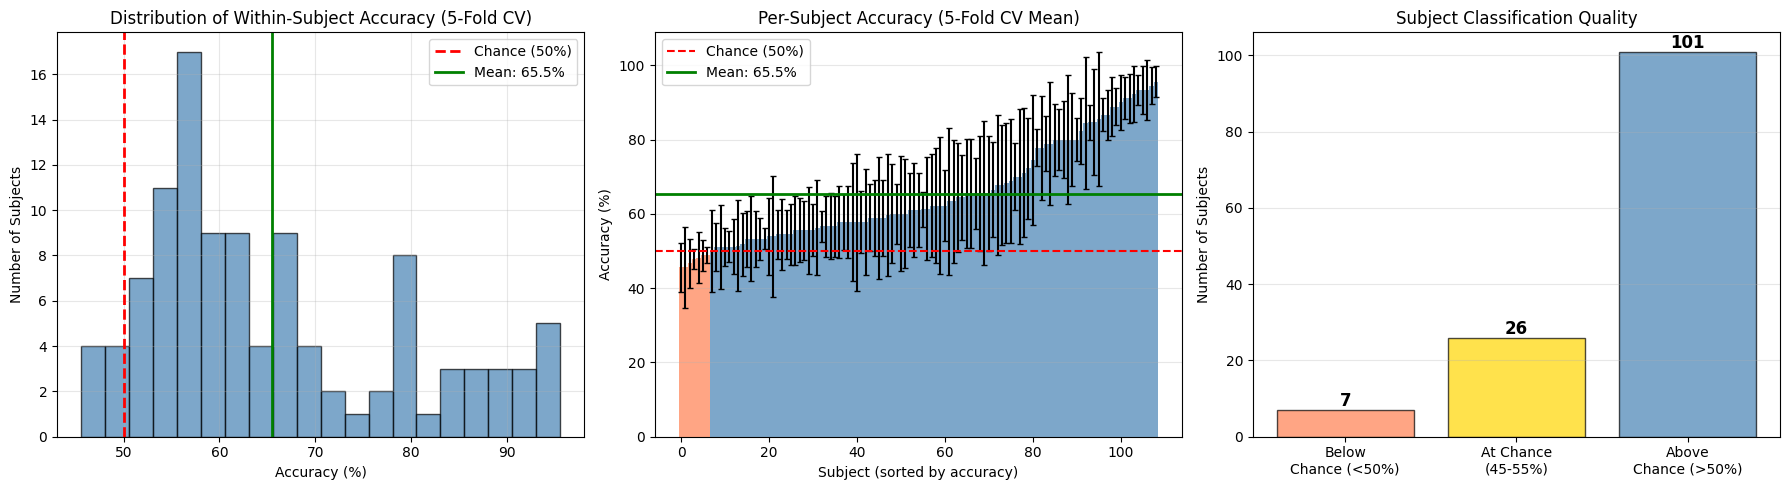


Summary:
  Above chance (>50%): 101/109 (92.7%)
  At chance (45-55%):  26/109
  Below chance (<50%): 7/109
  Mean: 65.5% +/- 13.5%


In [11]:
# Per-subject accuracy histogram + bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(within_accs * 100, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(x=50, color='red', ls='--', lw=2, label='Chance (50%)')
axes[0].axvline(x=within_accs.mean()*100, color='green', ls='-', lw=2,
                label=f'Mean: {within_accs.mean()*100:.1f}%')
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_ylabel('Number of Subjects')
axes[0].set_title('Distribution of Within-Subject Accuracy (5-Fold CV)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Per-subject bar chart (sorted by accuracy)
subjects_sorted = sorted(within_results, key=lambda r: r['accuracy'])
sids = [r['subject'] for r in subjects_sorted]
accs = [r['accuracy'] * 100 for r in subjects_sorted]
stds = [r['std'] * 100 for r in subjects_sorted]
colors = ['coral' if a < 50 else 'steelblue' for a in accs]
axes[1].bar(range(len(sids)), accs, yerr=stds, color=colors, alpha=0.7, width=1.0, capsize=2)
axes[1].axhline(y=50, color='red', ls='--', lw=1.5, label='Chance (50%)')
axes[1].axhline(y=within_accs.mean()*100, color='green', ls='-', lw=2,
                label=f'Mean: {within_accs.mean()*100:.1f}%')
axes[1].set_xlabel('Subject (sorted by accuracy)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Per-Subject Accuracy (5-Fold CV Mean)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Above-chance statistics
above_chance = np.sum(within_accs > 0.5)
at_chance = np.sum((within_accs >= 0.45) & (within_accs <= 0.55))
below_chance = np.sum(within_accs < 0.5)
categories = ['Below\nChance (<50%)', 'At Chance\n(45-55%)', 'Above\nChance (>50%)']
counts = [below_chance, at_chance, above_chance]
bar_colors = ['coral', 'gold', 'steelblue']
axes[2].bar(categories, counts, color=bar_colors, alpha=0.7, edgecolor='black')
for i, c in enumerate(counts):
    axes[2].text(i, c + 1, str(c), ha='center', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Number of Subjects')
axes[2].set_title('Subject Classification Quality')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eegtcnet_v2_physionet_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSummary:')
print(f'  Above chance (>50%): {above_chance}/{len(within_results)} ({above_chance/len(within_results)*100:.1f}%)')
print(f'  At chance (45-55%):  {at_chance}/{len(within_results)}')
print(f'  Below chance (<50%): {below_chance}/{len(within_results)}')
print(f'  Mean: {within_accs.mean()*100:.1f}% +/- {within_accs.std()*100:.1f}%')

## 12. Save Results

In [12]:
import os
os.makedirs('saved_models', exist_ok=True)

# Save results dictionary
results_dict = {r['subject']: {
    'accuracy_mean': float(r['accuracy']),
    'accuracy_std': float(r['std']),
    'fold_accs': [float(a) for a in r['fold_accs']],
    'n_trials': int(r['n_trials'])
} for r in within_results}
np.save('saved_models/eegtcnet_v2_physionet_results.npy', results_dict)
np.save('saved_models/eegtcnet_v2_physionet_accs.npy', within_accs)

# Save summary
above_chance = np.sum(within_accs > 0.5)
at_chance = np.sum((within_accs >= 0.45) & (within_accs <= 0.55))
below_chance = np.sum(within_accs < 0.5)

print('FINAL RESULTS: EEGTCNet v2 on PhysioNet')
print(f'Model: EEGTCNet v2 ({total_params:,} params)')
print(f'Dataset: PhysioNet ({len(within_results)} subjects, {N_CHANNELS}ch, {SFREQ}Hz)')
print(f'Runs: {MI_ME_RUNS} (execution + imagery)')
print(f'Augmentation: S&R ({SR_N_SEGMENTS} segments, {SR_N_AUGMENT} copies)')
print(f'Evaluation: {N_FOLDS}-fold stratified cross-validation')
print(f'')
print(f'Within-Subject Accuracy: {within_accs.mean()*100:.1f}% +/- {within_accs.std()*100:.1f}%')
print(f'  Min: {within_accs.min()*100:.1f}%, Max: {within_accs.max()*100:.1f}%')
print(f'  Median: {np.median(within_accs)*100:.1f}%')
print(f'  Above chance (>50%): {above_chance}/{len(within_results)}')
print(f'  At chance (45-55%):  {at_chance}/{len(within_results)}')
print(f'  Below chance (<50%): {below_chance}/{len(within_results)}')
print(f'  Chance: 50.0%')
print(f'')
print(f'Preprocessing: bandpass(8-30Hz) + CAR + z-score + EA')
print(f'Channels: {N_CHANNELS} selected motor cortex ({", ".join(SELECTED_CHANNELS)})')
print(f'Saved to: saved_models/eegtcnet_v2_physionet_*.npy')


FINAL RESULTS: EEGTCNet v2 on PhysioNet
Model: EEGTCNet v2 (72,178 params)
Dataset: PhysioNet (109 subjects, 16ch, 160Hz)
Runs: [3, 4, 7, 8, 11, 12] (execution + imagery)
Augmentation: S&R (8 segments, 8 copies)
Evaluation: 5-fold stratified cross-validation

Within-Subject Accuracy: 65.5% +/- 13.5%
  Min: 45.6%, Max: 95.6%
  Median: 61.1%
  Above chance (>50%): 101/109
  At chance (45-55%):  26/109
  Below chance (<50%): 7/109
  Chance: 50.0%

Preprocessing: bandpass(8-30Hz) + CAR + z-score + EA
Channels: 16 selected motor cortex (Fp1, F3, F4, C3, Cz, C4, P3, Pz, P4, F7, F8, T7, T8, P7, P8, Fz)
Saved to: saved_models/eegtcnet_v2_physionet_*.npy
